# **Unsupervised Learning Project**

**Students**

Alexandre Santos nº72970

David Natal nº72997

Miguel Mestre nº73018

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 100)

In [43]:
file_path = os.path.join("data", "hotel_bookings_course_release_v1.csv")

df = pd.read_csv(file_path)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [44]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

## EDA

In [45]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

#### Early Reservations VS Last minute

Text(0.5, 1.0, 'Distribution of Lead Time')

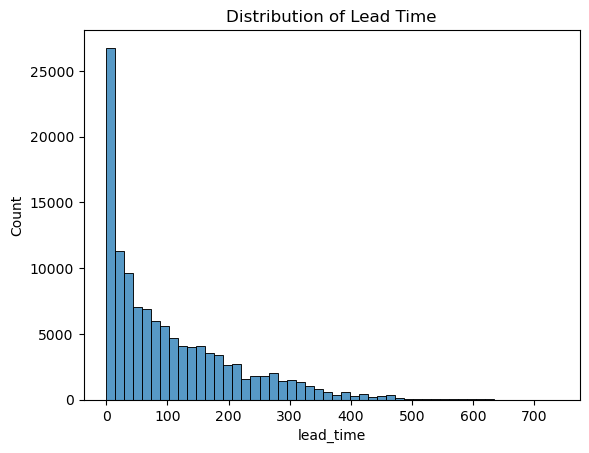

In [46]:
sns.histplot(df["lead_time"], bins=50)
plt.title("Distribution of Lead Time")

#### Price Fluctuation

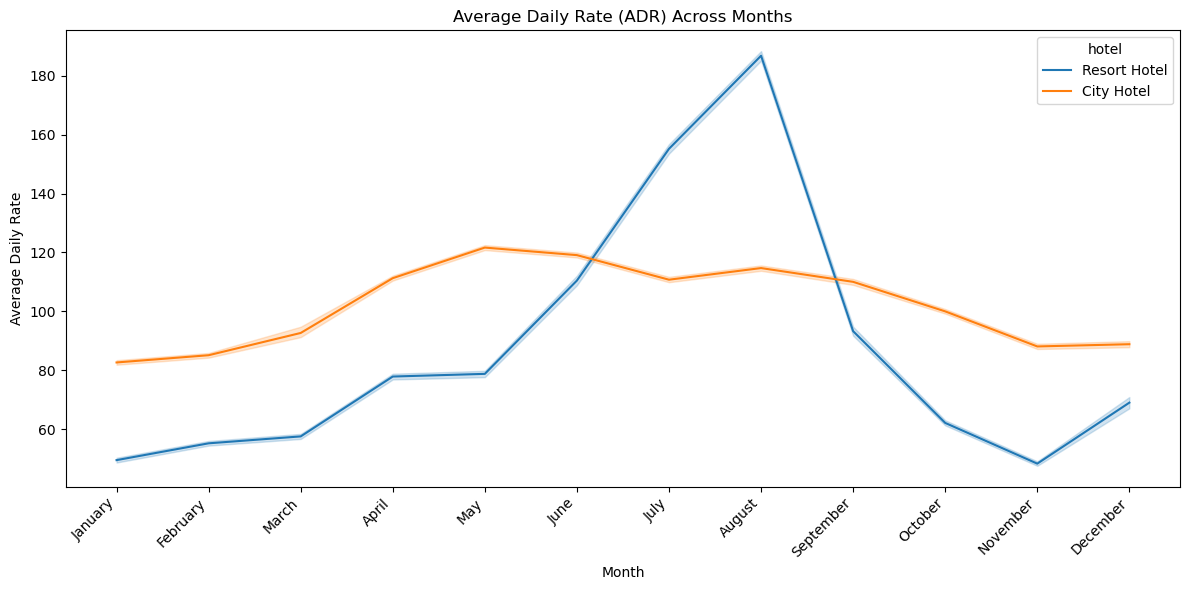

In [47]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

# Convert the column to an ordered categorical type
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months, ordered=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=df)

plt.xticks(rotation=45, ha='right') 
plt.title('Average Daily Rate (ADR) Across Months')
plt.ylabel('Average Daily Rate')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

#### Market Segmentation

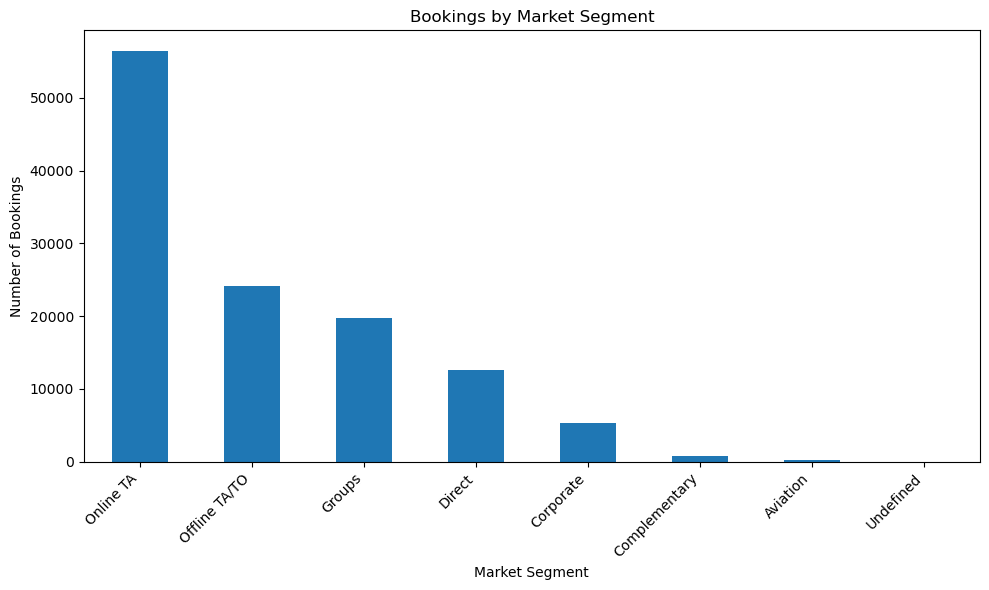

In [48]:
plt.figure(figsize=(10, 6))

market_counts = df['market_segment'].value_counts().plot(kind='bar')

plt.title('Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Categorical Variables Distribuitions

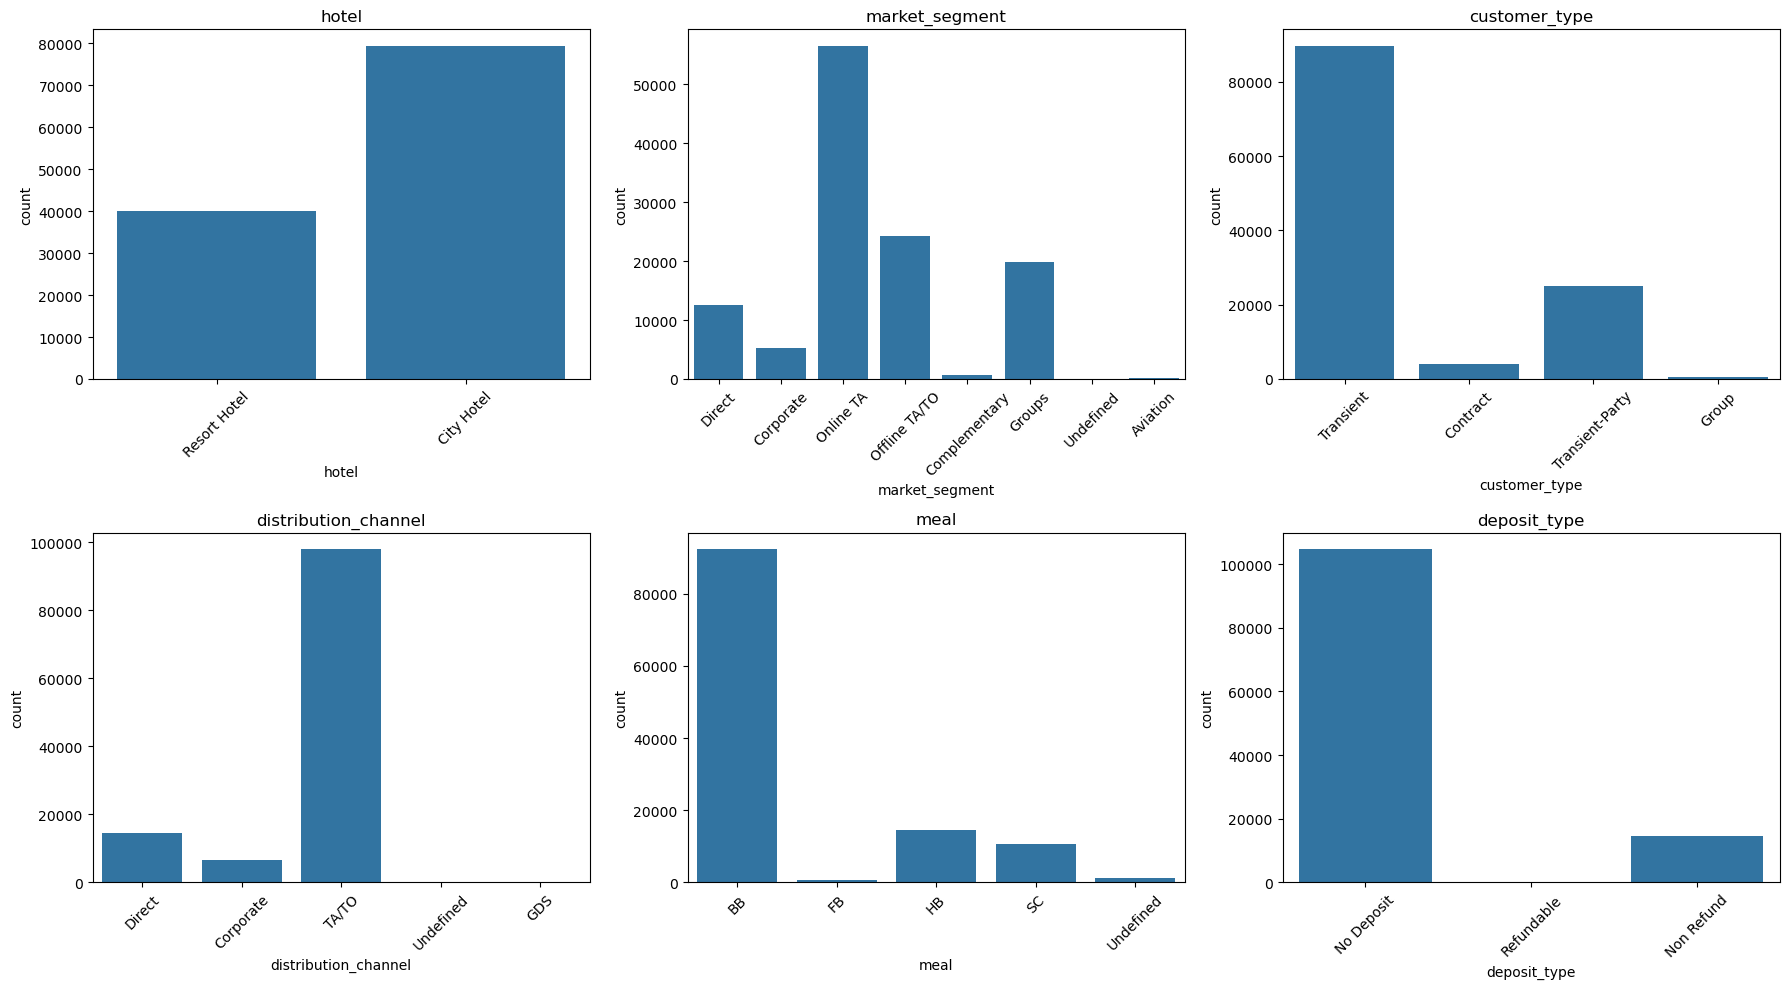

In [49]:
categorical_cols = [
    "hotel",
    "market_segment",
    "customer_type",
    "distribution_channel",
    "meal",
    "deposit_type"
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

for col, ax in zip(categorical_cols, axes.flatten()):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Reservations by Month

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'August'),
  Text(1, 0, 'July'),
  Text(2, 0, 'May'),
  Text(3, 0, 'October'),
  Text(4, 0, 'April'),
  Text(5, 0, 'June'),
  Text(6, 0, 'September'),
  Text(7, 0, 'March'),
  Text(8, 0, 'February'),
  Text(9, 0, 'November'),
  Text(10, 0, 'December'),
  Text(11, 0, 'January')])

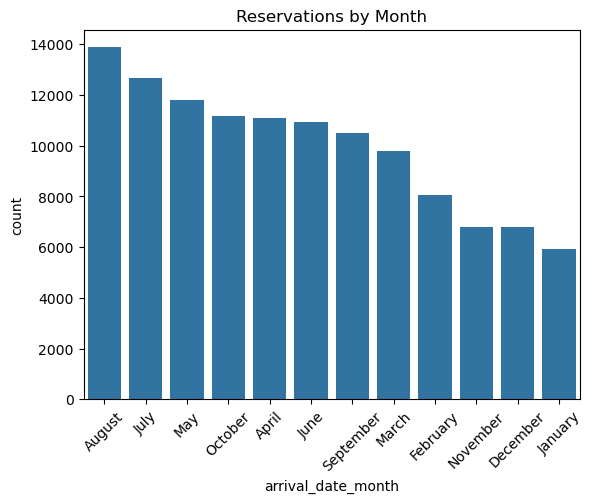

In [50]:
sns.countplot(x="arrival_date_month", data=df,
              order=df["arrival_date_month"].value_counts().index)
plt.title('Reservations by Month')
plt.xticks(rotation=45)

#### Number of Nights

Text(0.5, 1.0, 'Number of Nights')

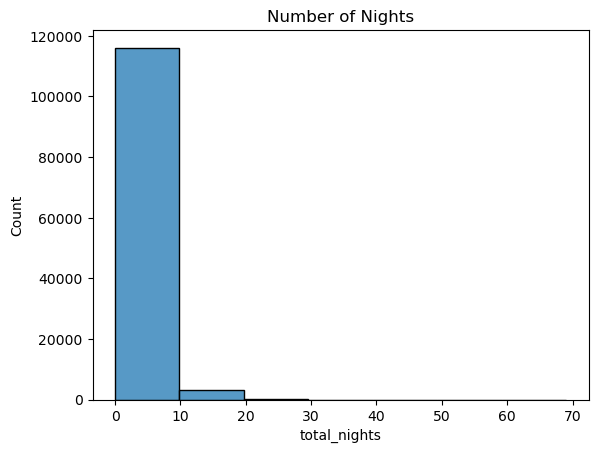

In [51]:
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

sns.histplot(df["total_nights"], bins=7)
plt.title('Number of Nights')

#### Lead time vs hotel

<Axes: xlabel='hotel', ylabel='lead_time'>

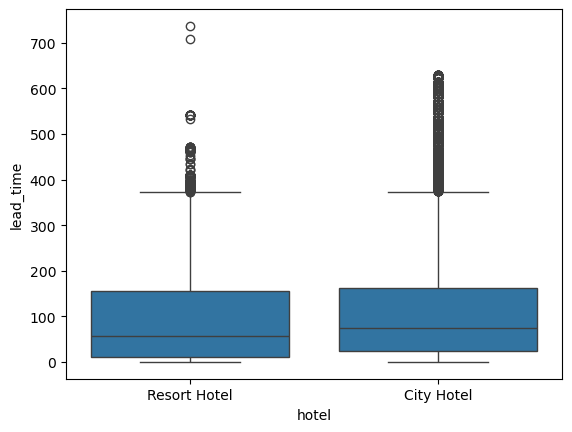

In [52]:
sns.boxplot(x="hotel", y="lead_time", data=df)

#### Cancelations

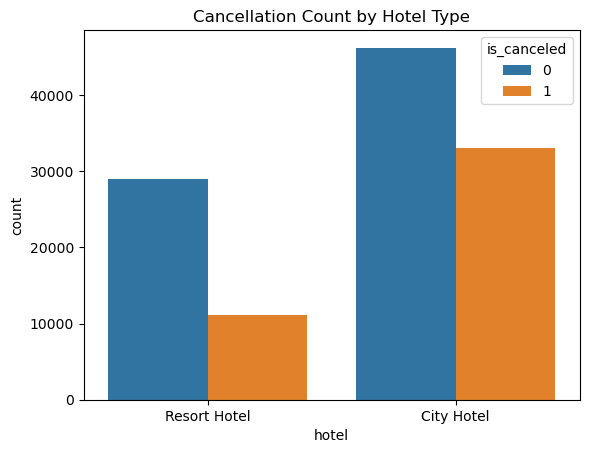

In [53]:
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title('Cancellation Count by Hotel Type')
plt.show()

## **Data preprocessing**

### Delete Variables

In [ ]:
# Leakage Control and high cardinality variables
drop_cols = [
"is_canceled",
"reservation_status",
"reservation_status_date",
"agent",
"company"
]

df = df.drop(columns=drop_cols)

## **Feature Engineering**

In [56]:
# Arrival Date
date_string = (df['arrival_date_day_of_month'].astype(str) + '-' + df['arrival_date_month'].astype(str) + '-' + df['arrival_date_year'].astype(str))
df['arrival_date'] = pd.to_datetime(date_string, format='%d-%B-%Y')
# df[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_date']].head()

# Total Nights
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

# Total Guests
df["total_guests"] = (df["adults"] + df["children"].fillna(0) + df["babies"]).astype(int)

# Room change to see upgrades and overbooking
df["room_changed"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

# Group rare countries
top_countries = df["country"].value_counts().nlargest(10).index
df["country"] = df["country"].apply(lambda x: x if x in top_countries else "Other")

df.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,arrival_date,total_guests,room_changed
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,0,2015-07-01,2,0
1,Resort Hotel,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,0,2015-07-01,2,0
2,Resort Hotel,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,1,2015-07-01,1,1
3,Resort Hotel,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,1,2015-07-01,1,0
4,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,2,2015-07-01,2,0


## **KMeans Clustering**

## **Evaluations Metrics**

## **Second Clustering Algorithm**

## **Stability Analysis**

## **Cluster Interpretation**